In [1]:
# #Uncomment these in a fresh notebook environment.
# %cd /content/marl-tsc
# %pip install -r requirements.txt
# %pip install -e .

In [2]:
#GITHUB --> COLAB CLONE / env setup
import os
from google.colab import userdata

# 1. Get your access token
token = userdata.get('GH_TOKEN')

# 2. Clone the repo if it's not already there
repo_path = '/content/marl-tsc'
if not os.path.exists(repo_path):
    !git clone --branch tom_new --single-branch https://{token}@github.com/abergh18/marl-tsc.git

# 3. CRUCIAL: Move to the root directory
# This ensures that 'import models' or 'import utils' works correctly
%cd {repo_path}


# 4. Install dependencies
!pip install -r requirements.txt

Cloning into 'marl-tsc'...
remote: Enumerating objects: 642, done.
remote: Counting objects: 100% (252/252), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 642 (delta 195), reused 123 (delta 123), pack-reused 390 (from 2)
Receiving objects: 100% (642/642), 1.97 MiB | 22.16 MiB/s, done.
Resolving deltas: 100% (329/329), done.
/content/marl-tsc
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.4 MB/s eta

In [3]:
!pip install eclipse-sumo libsumo
# For simulation
!apt-get install -y xvfb
!pip install pyvirtualdisplay

import os
os.environ["SUMO_HOME"] = "/usr/local/lib/python3.12/dist-packages/sumo"
os.environ["PATH"] += ":/usr/local/lib/python3.12/dist-packages/sumo/bin"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.1/147.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.2/236.2 kB 26.6 MB/s eta 0:00:00
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.26.0
    Uninstalling sumolib-1.26.0:
      Successfully uninstalled sumolib-1.26.0
  Attempting uninstall: traci
    Found existing installation: traci 1.26.0
    Uninstalling traci-1.26.0:
      Successfully uninstalled traci-1.26.0
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [4]:
from pathlib import Path
import sys
#Had to remove '.parent' for colab specific version
PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import traci
import sys

GREEN_PHASE_COUNT = 4

def print_comparison_table(rows):
  columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Mean max queue",
        "Mean waiting time",
        "Mean total time loss",
        "Total completed steps",
        "Mean switches / episode",
    ]

  def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

  widths = {column: len(column) for column in columns}
  for row in rows:
      for column in columns:
          widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

  header = " | ".join(column.ljust(widths[column]) for column in columns)
  separator = "-+-".join("-" * widths[column] for column in columns)
  print(header)
  print(separator)
  for row in rows:
      print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))

def reset_traci_connection():
    # Force clear TraCI's internal connection registries
    try:
        traci.switch("default")
        traci.close()
    except Exception:
        pass # No active connection to close

    try:
        # Completely purge the connection dictionary tracking connections
        if 'traci.main' in sys.modules:
            traci.main._connections.clear()
            print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        # Re-import fresh only if needed by subsequent code, otherwise it's handled by SumoTrafficEnv
    # print("TraCI state successfully reset!")

In [6]:
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"


## 1. Generate the SUMO simulation files



In [7]:
import shutil
from pathlib import Path
import os
import sys
import site

# Get the site-packages directory where eclipse-sumo is installed
site_packages = site.getsitepackages()[0]
sumo_path = Path(site_packages) / "sumo"

if not (sumo_path / "tools" / "randomTrips.py").exists():
    import sumo
    sumo_path = Path(sumo.__file__).parent

os.environ["SUMO_HOME"] = str(sumo_path)
os.environ["PATH"] += f":{sumo_path}/bin"
print(f"SUMO_HOME set to: {os.environ['SUMO_HOME']}")

# ==========================================
# MASTER VARIABLE: Controls the entire run
# ==========================================
EPISODE_STEPS = 1000

# ==========================================
# Derived Parameters
# ==========================================
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

NUM_EPISODES = 30
EVALUATION_EPISODES = 10
TOTAL_TIMESTEPS = EPISODE_STEPS * 200
MIN_GREEN_SECONDS = 10

# ==========================================
# Generator Configuration
# ==========================================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

vtypes_content = """<additional>
    <vType id="car"    vClass="passenger" speedFactor="normc(1,0.1,0.2,2)" length="4.5" maxSpeed="50"/>
    <vType id="van"    vClass="delivery"  speedFactor="normc(0.9,0.1,0.2,2)" length="6.0" maxSpeed="40"/>
    <vType id="bus"    vClass="bus"       speedFactor="normc(0.85,0.05,0.2,2)" length="12.0" maxSpeed="30"/>
</additional>"""

vtypes_file = OUTPUT_DIR / "vtypes.xml"
vtypes_file.write_text(vtypes_content)

network_file_name = "york_cleaned.net.xml"

net_path_in_output = OUTPUT_DIR / network_file_name

potential_source_paths = [
    Path('/content') / network_file_name,
    Path('/content/marl-tsc') / network_file_name,
    Path.cwd() / network_file_name,
    net_path_in_output,
]

found_source_path = None
for p in potential_source_paths:
    if p.exists():
        found_source_path = p
        print(f"Found network file at: {p}")
        break

if found_source_path is None:
    print(f"ERROR: Network file '{network_file_name}' not found.")
    raise FileNotFoundError(f"Network file '{network_file_name}' is missing.")
elif found_source_path.resolve() != net_path_in_output.resolve():
    shutil.copy2(found_source_path, net_path_in_output)
    print(f"Copied network file to {net_path_in_output}")

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    network_filename=network_file_name,
    trip_fringe_factor=10,
    allow_fringe=True,
    trip_period=0.8,
    min_distance=200,
    vtypes_file=vtypes_file,
)
generator.generate_peak_trips(
    peak_end=int(SIMULATION_DURATION * 0.4),
    peak_period=1.0,
    offpeak_period=3.5,
)
generator.generate_config()

tls_in_net = list(generator.traffic_light_ids)
paths = generator.paths

print(f"Scenario configured using: {paths.config_file}")
print(f"Traffic light agents ({len(tls_in_net)}): {tls_in_net}")

SUMO_HOME set to: /usr/local/lib/python3.12/dist-packages/sumo
Found network file at: /content/marl-tsc/york_cleaned.net.xml
Copied network file to /content/marl-tsc/outputs/york_cleaned.net.xml
Discovered 10 traffic lights: ['joinedS_1629111685_8236824230_8236824233_cluster_1629111693_1629111709_1629111723_27497547_#1more_#1more', 'cluster_27497557_280867238_9209477353_9209477354', '9188508158', 'joinedS_21268486_9146743323_cluster_1435273283_1435273297_1435273300_21268487_#1more', '1709832578', '9174145494', 'cluster_2320517021_2320517022_8236824244', 'joinedS_12728487_8233484841_8233484843_cluster_27231337_703830048_#1more', 'cluster_12728484_9209477371_9209477372', 'cluster_1430554973_316116508_8236824245']
Scenario configured using: /content/marl-tsc/outputs/config.sumocfg
Traffic light agents (10): ['joinedS_1629111685_8236824230_8236824233_cluster_1629111693_1629111709_1629111723_27497547_#1more_#1more', 'cluster_27497557_280867238_9209477353_9209477354', '9188508158', 'joinedS_

In [27]:
# Add this temporarily to your evaluation loop to see how often switching is allowed
reset_traci_connection()
from marl_tsc.traffic_env import SumoTrafficEnv

env = SumoTrafficEnv(
    paths.config_file,
    possible_agents=tls_in_net,
    max_steps=50,
    seed=42,
    min_green_seconds=MIN_GREEN_SECONDS,
)

observations, infos = env.reset(seed=42)
for step in range(20):
    first_agent = tls_in_net[0]
    mask = infos[first_agent]["action_mask"]
    current = env._current_actions.get(first_agent, 0)
    elapsed = env._elapsed_green_seconds.get(first_agent, 0)
    print(f"Step {step:2d} | current phase: {current} | elapsed: {elapsed:.0f}s | mask: {mask} | can switch: {mask.sum() > 1}")

    actions = mappo_model.act(observations, infos=infos)
    observations, _, _, _, infos = env.step(actions)

env.close()

 Retrying in 1 seconds
 Retrying in 1 seconds
Step  0 | current phase: 0 | elapsed: 0s | mask: [1. 0. 0. 0.] | can switch: False


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x19 and 27x256)

## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [28]:
import traci
import sys

# ==========================================
# 1. RANDOM BASELINE EVALUATION
# ==========================================
reset_traci_connection()
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=None,             # Dynamically extract from the net file
    policy=random_actions,
    episodes=1,
    max_steps=600,
    seed=42,
    env_kwargs={
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION
    },
)

# ==========================================
# 2. FIXED-TIME BASELINE EVALUATION
# ==========================================
reset_traci_connection()
fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    policy=fixed_time_actions,
    episodes= 1,
    max_steps= 600,
    seed=42,
    env_kwargs={
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
    },
)

 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/1 - Total Reward: -10.74
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/1 - Total Reward: -8.12


In [11]:
baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Mean max queue": random_result["mean_max_queue"],
        "Mean waiting time": random_result["mean_waiting_time"],
        "Mean total time loss": random_result["mean_total_time_loss"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed-Time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Mean max queue": fixed_time_result["mean_max_queue"],
        "Mean waiting time": fixed_time_result["mean_waiting_time"],
        "Mean total time loss": fixed_time_result["mean_total_time_loss"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]

print_comparison_table(baseline_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Mean max queue | Mean waiting time | Mean total time loss | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+----------------+-------------------+----------------------+-----------------------+------------------------
Random     | 1        | -10.740           | 0.031            | 8.000          | 11.398            | 3899.157             | 219                   | 63.000                 
Fixed-Time | 1        | -8.122            | 0.024            | 5.000          | 14.325            | 3634.730             | 223                   | 57.000                 


## 3. Train

 MAPPO adds a centralized critic and a shared decentralized actor.


### MAPPO

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -0.64 | Total Steps: 100
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -0.35 | Total Steps: 200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -0.57 | Total Steps: 300
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -0.43 | Total Steps: 400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -0.54 | Total Steps: 500
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -0.22 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -0.40 | Total Steps: 700
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -0.43 | Total Steps: 800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -0.27 | Total Steps: 900
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -0.35 | Total Steps: 1000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -0.23 | Total Steps: 1100
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -0.31 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 13 | Return: -0.35 |

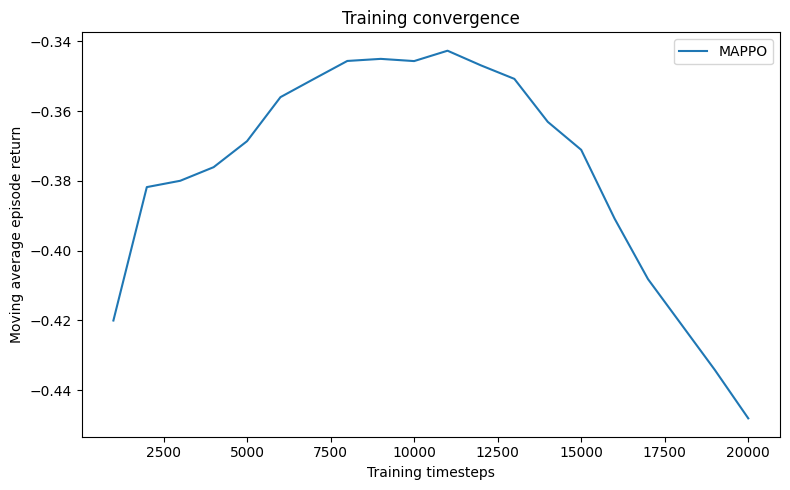

Saved MAPPO model: /content/marl-tsc/outputs/models/mappo.pt


In [12]:
reset_traci_connection()
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1000,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"min_green_seconds": MIN_GREEN_SECONDS},
    use_peer_reward=False,
)

fig, ax = plot_training_histories(mappo_history)
plt.show()
print("Saved MAPPO model:", mappo_model_path)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: 0.00 | Total Steps: 100
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: 0.09 | Total Steps: 200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: 0.09 | Total Steps: 300
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -0.04 | Total Steps: 400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: 0.05 | Total Steps: 500
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: 0.04 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: 0.19 | Total Steps: 700
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: 0.19 | Total Steps: 800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: 0.28 | Total Steps: 900
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -0.01 | Total Steps: 1000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: 0.19 | Total Steps: 1100
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: 0.22 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 13 | Return: 0.05 | Total Step

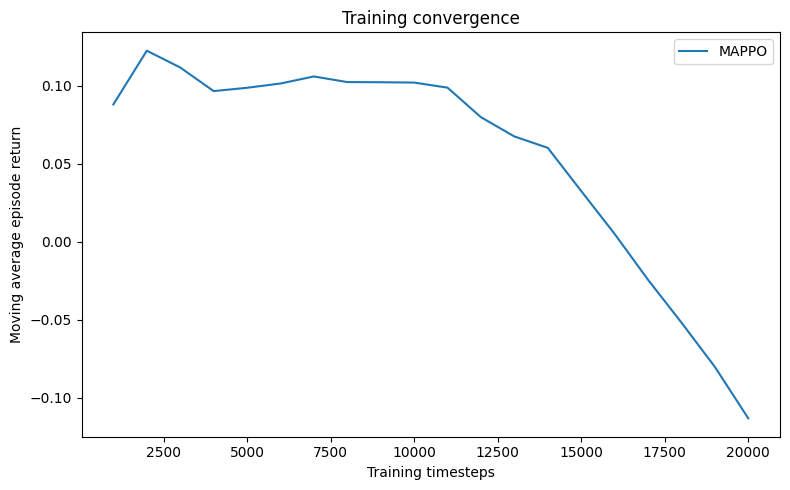

Saved Gifting MAPPO model: /content/marl-tsc/outputs/models/mappo_peer_reward.pt


In [13]:
reset_traci_connection()
gifting_mappo_model, gifting_mappo_history, gifting_mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=1000,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"min_green_seconds": MIN_GREEN_SECONDS},
    use_peer_reward=True,
)

fig, ax = plot_training_histories(gifting_mappo_history)
plt.show()
print("Saved Gifting MAPPO model:", gifting_mappo_model_path)

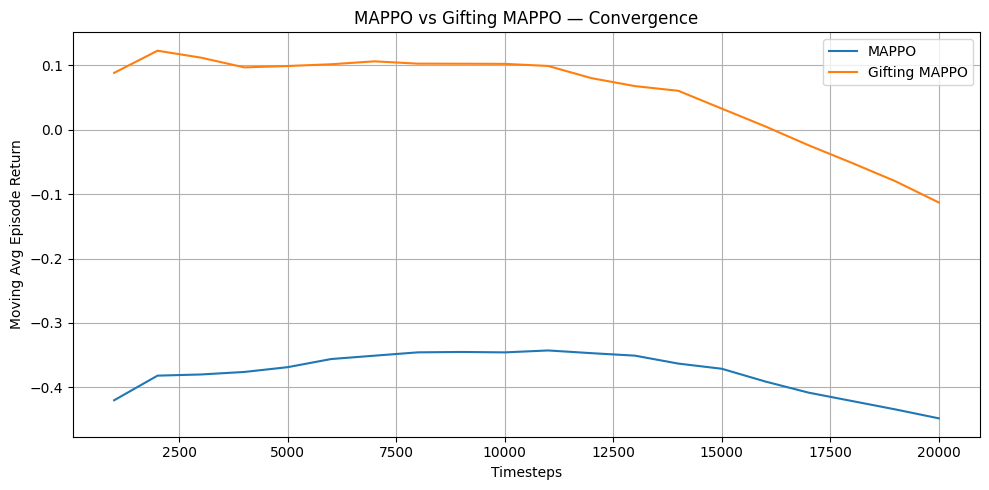

In [14]:
def plot_convergence_comparison(histories: dict[str, list[dict]]):
    fig, ax = plt.subplots(figsize=(10, 5))

    for label, history in histories.items():
        timesteps = [h["timestep"] for h in history]
        returns = [h["moving_avg_episode_return"] for h in history]
        ax.plot(timesteps, returns, label=label)

    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Moving Avg Episode Return")
    ax.set_title("MAPPO vs Gifting MAPPO — Convergence")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_convergence_comparison({
    "MAPPO": mappo_history,
    "Gifting MAPPO": gifting_mappo_history,
})

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [15]:
reset_traci_connection()
mappo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    policy=mappo_model,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
    },
)

reset_traci_connection()
gifting_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    policy=gifting_mappo_model,
    episodes=1,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
    },
)

 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/1 - Total Reward: -6.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/1 - Total Reward: -2.06


In [16]:
final_comparison_rows = baseline_rows.copy()

final_comparison_rows.append({
    "Policy": "MAPPO",
    "Episodes": mappo_result["episodes"],
    "Mean total reward": mappo_result["mean_total_reward"],
    "Mean local queue": mappo_result["mean_local_queue"],
    "Mean max queue": mappo_result["mean_max_queue"],
    "Mean waiting time": mappo_result["mean_waiting_time"],
    "Mean total time loss": mappo_result["mean_total_time_loss"],
    "Total completed steps": mappo_result["total_completed_steps"],
    "Mean switches / episode": mappo_result["mean_switches_per_episode"],
})

final_comparison_rows.append({
    "Policy": "Gifting MAPPO",
    "Episodes": gifting_mappo_result["episodes"],
    "Mean total reward": gifting_mappo_result["mean_total_reward"],
    "Mean local queue": gifting_mappo_result["mean_local_queue"],
    "Mean max queue": gifting_mappo_result["mean_max_queue"],
    "Mean waiting time": gifting_mappo_result["mean_waiting_time"],
    "Mean total time loss": gifting_mappo_result["mean_total_time_loss"],
    "Total completed steps": gifting_mappo_result["total_completed_steps"],
    "Mean switches / episode": gifting_mappo_result["mean_switches_per_episode"],
})

print("\n=== Final Performance Comparison ===")
print_comparison_table(final_comparison_rows)


=== Final Performance Comparison ===
Policy        | Episodes | Mean total reward | Mean local queue | Mean max queue | Mean waiting time | Mean total time loss | Total completed steps | Mean switches / episode
--------------+----------+-------------------+------------------+----------------+-------------------+----------------------+-----------------------+------------------------
Random        | 1        | -10.740           | 0.031            | 8.000          | 11.398            | 3899.157             | 219                   | 63.000                 
Fixed-Time    | 1        | -8.122            | 0.024            | 5.000          | 14.325            | 3634.730             | 223                   | 57.000                 
MAPPO         | 1        | -6.067            | 0.039            | 4.000          | 18.849            | 7033.752             | 100                   | 3.000                  
Gifting MAPPO | 1        | -2.061            | 0.039            | 4.000          | 18.849   

In [17]:
import subprocess

def clean_up_sumo_processes():
    """Forcefully terminate any stuck SUMO or TraCI background processes."""
    subprocess.run(["pkill", "-9", "sumo"], capture_output=True)
    subprocess.run(["pkill", "-9", "sumo-gui"], capture_output=True)


clean_up_sumo_processes()

In [18]:
import subprocess
from pathlib import Path

def save_sumo_trace(
    config_file,
    traffic_light_ids,
    policy,
    output_dir,
    max_steps=600,
    seed=42,
    env_kwargs=None,
    filename="simulation_trace.xml",
):
    from marl_tsc.traffic_env import SumoTrafficEnv

    output_dir = Path(output_dir)
    trace_path = output_dir / filename

    env = None
    try:
        env = SumoTrafficEnv(
            config_file,
            possible_agents=traffic_light_ids,
            max_steps=max_steps,
            seed=seed,
            render_mode=None,
            **(env_kwargs or {}),
        )
        observations, infos = env.reset(seed=seed)

        for step in range(max_steps):
            actions = policy.act(observations, infos=infos)
            observations, rewards, terminations, truncations, infos = env.step(actions)
            if any(terminations.values()) or any(truncations.values()):
                break

    finally:
        if env is not None:
            env.close()

    print(f"Trace saved to: {trace_path}")
    return trace_path


reset_traci_connection()

save_sumo_trace(
    config_file=paths.config_file,
    traffic_light_ids=tls_in_net,
    policy=mappo_model,
    output_dir=OUTPUT_DIR,
    max_steps=600,
    seed=42,
    env_kwargs={
        "green_phase_count": 8,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
    },
)

 Retrying in 1 seconds
 Retrying in 1 seconds
Trace saved to: /content/marl-tsc/outputs/simulation_trace.xml


PosixPath('/content/marl-tsc/outputs/simulation_trace.xml')

### Traci Escape Hatch

In [19]:
on = True
if on:
    # Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
    import sys

    # 1. Force clear TraCI's internal connection registries
    try:
        import traci
        traci.switch("default")
        traci.close()
    except Exception:
        pass

    try:
        # Completely purge the connection dictionary tracking connections
        import traci.main
        traci.main._connections.clear()
        print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # 2. Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        print("Flushed TraCI module from Python runtime memory.")

    # 3. Re-import fresh
    import traci
    print("TraCI state successfully reset!")

Flushed TraCI module from Python runtime memory.
TraCI state successfully reset!


# Graph Stuff


In [20]:
generator_graphs = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=2_000,#TRAFFIC_SPAWN_DURATION,  # TEMPORARY TEST
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

NameError: name 'traffic_light_ids' is not defined

In [ ]:
#paths = generator_graphs.generate_all()
paths = generator.generate_all()

### Environment and Smoke Tests

In [ ]:
from marl_tsc.graph_based.graph_builder import GraphBuilder

builder = GraphBuilder(paths.network_file)

topology = builder.build()
print("Topology output:")
print("List of Nodes")
print(topology.agent_ids)
print("Edge Index:Columns Represent source --> Target")
print(topology.edge_index)

In [ ]:
tls = next(iter(builder.net.getTrafficLights()))

connections = tls.getConnections()

print(connections[0])

incoming_lane = connections[0][0]
outgoing_lane = connections[0][1]

print(type(incoming_lane))
print(type(outgoing_lane))

print(sorted(
    attr
    for attr in dir(incoming_lane)
    if not attr.startswith("_")
)[:50])

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for agent in topology.agent_ids:
    G.add_node(agent)

for src, dst in topology.edge_index.t().tolist():
    G.add_edge(
        topology.agent_ids[src],
        topology.agent_ids[dst]
    )

plt.figure(figsize=(6, 6))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
)

plt.show()

In [ ]:
from marl_tsc.graph_based.graph_builder import GraphBuilder
from marl_tsc.graph_based.graph_env import GraphTrafficEnv

from marl_tsc.graph_based.encoders.gat_encoder import GATEncoder

from marl_tsc.graph_based.models.actor import ActorHead
from marl_tsc.graph_based.models.critic import CriticHead
from marl_tsc.graph_based.models.graph_policy import GraphPolicy


# ------------------------------------------------------------------
# 1. Build graph topology
# ------------------------------------------------------------------

topology = GraphBuilder(
    paths.network_file
).build()

print("Agents:", topology.agent_ids)
print("Edge Index Shape:", topology.edge_index.shape)

assert len(topology.agent_ids) > 0
assert topology.edge_index.shape[0] == 2


# ------------------------------------------------------------------
# 2. Create graph environment
# ------------------------------------------------------------------

from marl_tsc.wrappers import PeerRewardingWrapper

env = GraphTrafficEnv(
    config_file=paths.config_file,
    network_file=paths.network_file,
    possible_agents=topology.agent_ids,
    max_steps=100,
    seed=42,
)

# Fix: Manually set possible_agents as an attribute if GraphTrafficEnv doesn't store it.
# This ensures the PeerRewardingWrapper can access it.
env.possible_agents = topology.agent_ids

# Fix for `action_space` AttributeError:
# The PeerRewardingWrapper expects env.action_space(agent_id) to be a callable method.
# If GraphTrafficEnv defines `action_spaces` as a dictionary property but not this method,
# we need to dynamically add the `action_space` method to the env instance.
if not hasattr(env, 'action_space') or not callable(getattr(env, 'action_space', None)):
    # This assumes GraphTrafficEnv populates `self.action_spaces` internally.
    # If this assumption is incorrect, further inspection of GraphTrafficEnv's source is needed.
    if hasattr(env, 'action_spaces') and isinstance(env.action_spaces, dict):
        def _get_action_space_for_agent(agent_id):
            return env.action_spaces[agent_id]
        env.action_space = _get_action_space_for_agent
    else:
        raise AttributeError(
            "GraphTrafficEnv instance lacks a callable 'action_space' method "
            "and does not appear to expose 'action_spaces' as a dictionary. "
            "Cannot proceed with PeerRewardingWrapper."
        )


# Apply the wrapper to the environment
env = PeerRewardingWrapper(env, division=10)

graph_obs, infos = env.reset(seed=42)

print("\nGraph:")
print(graph_obs)

assert graph_obs.graph.x.shape[0] == len(topology.agent_ids)
assert graph_obs.graph.edge_index.shape[0] == 2


# ------------------------------------------------------------------
# 3. Encoder
# ------------------------------------------------------------------

obs_dim = graph_obs.graph.x.shape[1]

encoder = GATEncoder(
    obs_dim=obs_dim,
    hidden_dim=64,
)

encoder_output = encoder(graph_obs)

print("\nEncoder:")
print("Node Embeddings:", encoder_output.node_embeddings.shape)
print("Graph Embedding:", encoder_output.graph_embedding.shape)

assert encoder_output.node_embeddings.shape == (
    len(topology.agent_ids),
    64,
)

assert encoder_output.graph_embedding.shape == (64,)


# ------------------------------------------------------------------
# 4. Heads
# ------------------------------------------------------------------

# Get the MultiDiscrete action sizes for the first agent
# e.g., this will return an array like [8, 11]
action_dims = env.action_space(topology.agent_ids[0]).nvec

# In the provided code, `action_dim` is used later which is undefined.
# If `action_dims` is a list, `action_dim` should refer to its sum or a specific element.
# Assuming it should refer to the sum of action dimensions for the `actor` head.
# Given the context of `MultiDiscrete`, it's often the product or sum depending on interpretation.
# For a single agent with MultiDiscrete actions, `action_dims` would be `[num_actions_branch1, num_actions_branch2]`.
# The `ActorHead` expects `action_dims` to be a list/tuple of these sizes. It is correctly passed as `action_dims`.
# The assertion `assert logits.shape == (len(topology.agent_ids), action_dim,)`
# implies that `action_dim` should be the total number of actions *per agent*.
# Let's define `action_dim` as the sum of elements in `action_dims` for the assertion.
action_dim = sum(action_dims) if hasattr(action_dims, '__iter__') else action_dims

actor = ActorHead(
    embedding_dim=64,
    action_dims=action_dims,
)

critic = CriticHead(
    embedding_dim=64,
)

logits = actor(encoder_output)
value = critic(encoder_output)

print("\nHeads:")
print("Logits:", logits.shape)
print("Value:", value.shape)

assert logits.shape == (
    len(topology.agent_ids),
    action_dim,
)

assert value.shape == (1,)


# ------------------------------------------------------------------
# 5. Full policy
# ------------------------------------------------------------------

policy = GraphPolicy(
    encoder=encoder,
    actor_head=actor,
    critic_head=critic,
)

output = policy(graph_obs)

print("\nPolicy:")
print("Policy Logits:", output.logits.shape)
print("Policy Value:", output.value.shape)

assert output.logits.shape == (
    len(topology.agent_ids),
    action_dim,
)

assert output.value.shape == (1,)

print("\nGRAPH STACK SMOKE TEST PASSED")

env.close()

In [ ]:
import torch
import torch_geometric
from marl_tsc.graph_based.graph_runner import GraphRunner
from marl_tsc.graph_based.graph_rollout import GraphRollout
from marl_tsc.graph_based.advantage_estimator import (
    AdvantageEstimator,
)

# --------------------------------------------------
# 1. Collect rollout
# --------------------------------------------------

runner = GraphRunner(
    env=env,
    policy=policy,
)

rollout = runner.collect_rollout(
    num_steps=10,
    seed=42,
)

print("Transitions:", len(rollout))

assert len(rollout) > 0

# --------------------------------------------------
# 2. Transition checks
# --------------------------------------------------

first = rollout[0]

print("\nTransition:")
print(type(first))

print("Actions:", first.action_dict)
print("Log Prob Shape:", first.log_prob.shape)
print("Logits Shape:", first.logits.shape)
print("Value Shape:", first.value.shape)

assert first.log_prob.shape == (
    len(topology.agent_ids),
)

assert first.logits.shape[0] == len(
    topology.agent_ids
)

assert first.value.shape == (1,)

# --------------------------------------------------
# 3. Rollout batch
# --------------------------------------------------

batch = GraphRollout.from_transitions(
    rollout,
    topology.agent_ids,
)

print("\nRollout Batch:")
print("Actions:", batch.actions.shape)
print("Log Probs:", batch.log_probs.shape)
print("Logits:", batch.logits.shape)
print("Values:", batch.values.shape)
print("Rewards:", batch.rewards.shape)
print("Dones:", batch.dones.shape)

assert batch.actions.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.log_probs.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.rewards.shape == (
    len(rollout),
    len(topology.agent_ids),
)

assert batch.values.shape == (
    len(rollout),
)

assert batch.dones.shape == (
    len(rollout),
)

# --------------------------------------------------
# 4. Advantage estimation
# --------------------------------------------------

adv_batch = (
    AdvantageEstimator
    .compute_gae(batch)
)

print("\nAdvantages:")
print(
    "Advantages:",
    adv_batch.advantages.shape,
)

print(
    "Returns:",
    adv_batch.returns.shape,
)

assert (
    adv_batch.advantages.shape
    ==
    batch.values.shape
)

assert (
    adv_batch.returns.shape
    ==
    batch.values.shape
)

assert not torch.isnan(
    adv_batch.advantages
).any()

assert not torch.isnan(
    adv_batch.returns
).any()

# --------------------------------------------------
# 5. Sample outputs
# --------------------------------------------------

print("\nSample Values")

print(
    "Advantages:",
    adv_batch.advantages[:5]
)

print(
    "Returns:",
    adv_batch.returns[:5]
)

print(
    "\n✅ PHASE 2 GRAPH ROLLOUT PIPELINE PASSED"
)

In [ ]:
def evaluate_policy(env, policy, steps=100):

    graph_obs, infos = env.reset()

    total_reward = 0

    for _ in range(steps):

        output = policy(graph_obs)

        actions = output.logits.argmax(
            dim=1
        )

        action_dict = {
            agent_id: int(action)
            for agent_id, action in zip(
                graph_obs.agent_ids,
                actions,
            )
        }

        (
            graph_obs,
            rewards,
            terms,
            truncs,
            infos,
        ) = env.step(action_dict)

        total_reward += sum(
            rewards.values()
        )

    return total_reward

In [ ]:
num_params = sum(
    p.numel()
    for p in policy.parameters()
)

print(
    f"Trainable parameters: {num_params:,}"
)

In [ ]:
import copy

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=2e-4,
)

from marl_tsc.graph_based.graph_ctde_trainer import (
    GraphCTDETrainer,
)

trainer = GraphCTDETrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=10,
)

before = copy.deepcopy(
    next(
        policy.parameters()
    ).detach()
)

stats = trainer.train_step()

after = next(
    policy.parameters()
).detach()

print(stats)

print(
    torch.equal(
        before,
        after,
    )
)

In [ ]:
import importlib

import marl_tsc.graph_based.graph_runner

importlib.reload(
    #marl_tsc.graph_based.graph_runner,
    marl_tsc.graph_based.graph_rollout
)

from marl_tsc.graph_based.graph_runner import GraphRunner
import marl_tsc.graph_based.graph_rollout

In [ ]:
import torch

# ----------------------------------
# Evaluation helper
# ----------------------------------

def evaluate_policy(env, policy, steps=100):

    graph_obs, _ = env.reset()

    total_reward = 0.0

    for _ in range(steps):

        with torch.no_grad():
            output = policy(graph_obs)

            # Unpack the two sets of logits
            traffic_logits, sharing_logits = output.logits

            # Get the best action for both branches
            traffic_actions = traffic_logits.argmax(dim=1)
            sharing_actions = sharing_logits.argmax(dim=1)

        # Combine them into a list for the environment
        action_dict = {
            agent_id: [int(t_act), int(s_act)]
            for agent_id, t_act, s_act in zip(
                graph_obs.agent_ids,
                traffic_actions,
                sharing_actions,
            )
        }

        (
            graph_obs,
            rewards,
            terminations,
            truncations,
            infos,
        ) = env.step(action_dict)

        total_reward += sum(
            rewards.values()
        )

        if any(truncations.values()):
            break

    return total_reward


# ----------------------------------
# Fresh optimizer
# ----------------------------------

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3,
)

# ----------------------------------
# Trainer
# ----------------------------------

trainer = GraphCTDETrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=64,
)

# ----------------------------------
# Baseline evaluation
# ----------------------------------

before_reward = evaluate_policy(
    env,
    policy,
)

print(f"Before Training: {before_reward:.4f}")

# ----------------------------------
# Train
# ----------------------------------

for iteration in range(100):

    stats = trainer.train_step()

    if (iteration + 1) % 10 == 0:

        print(
            f"Iter {iteration + 1:3d} | "
            f"Actor {stats['actor_loss']:.4f} | "
            f"Critic {stats['critic_loss']:.4f}"
        )

# ----------------------------------
# Final evaluation
# ----------------------------------

after_reward = evaluate_policy(
    env,
    policy,
)

print()
print(f"After Training:  {after_reward:.4f}")
print(f"Improvement:     {after_reward - before_reward:.4f}")

# ----------------------------------
# Inspect learned policy
# ----------------------------------

graph_obs, _ = env.reset()

with torch.no_grad():

    output = policy(graph_obs)

print()
print("Greedy Actions:")
print(output.logits.argmax(dim=1))

print()
print("Logits:")
print(output.logits)

In [ ]:
def eval_constant(env, action, steps=100):

    graph_obs, _ = env.reset()

    total_reward = 0

    for _ in range(steps):

        action_dict = {
            agent: action
            for agent in env.agent_ids
        }

        graph_obs, rewards, *_ = env.step(
            action_dict
        )

        total_reward += sum(
            rewards.values()
        )

    return total_reward


print(eval_constant(env, 0))
print(eval_constant(env, 1))
print(eval_constant(env, 2))
print(eval_constant(env, 3))

In [ ]:
from marl_tsc.graph_based.base_trainer import BaseGraphTrainer


class DummyTrainer(BaseGraphTrainer):

    def update(
        self,
        rollout_batch,
        advantage_batch,
    ):

        print(type(rollout_batch))
        print(type(advantage_batch))

        print()

        print("Actions:")
        print(rollout_batch.actions.shape)

        print()

        print("Advantages:")
        print(advantage_batch.advantages.shape)

        print()

        print("Returns:")
        print(advantage_batch.returns.shape)

        return {
            "dummy_loss": 0.0,
        }


trainer = DummyTrainer(
    env=env,
    policy=policy,
    optimizer=optimizer,
    rollout_steps=10,
)

stats = trainer.train_step()

print()
print(stats)

In [ ]:
from marl_tsc.graph_based.train_graph_ctde import (
    train_graph_ctde,
)

model, history, model_path = (
    train_graph_ctde(
        config_file=paths.config_file,
        network_file=paths.network_file,
        traffic_light_ids=traffic_light_ids,
        output_dir=OUTPUT_DIR,
        total_timesteps=1000,
        rollout_steps=64,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
        },
    )
)

print(type(model))
print(len(history))
print(model_path)
print(history[-1])

In [ ]:
fig, ax = plot_training_histories(history)
plt.show()

#### Git stuff

In [ ]:
!git status


In [ ]:
!git add .

In [ ]:
import shlex
commit_msg = '''
Bug within GraphCTDETrainer. Needs commiting before reloading notebook
'''
'''
TODO:
- Heterogenous networks
- Full Training run on bigger networks
- Possible integration with Andy's updated code
- Possible integration with Tom's networks
'''

In [ ]:
print(commit_msg)

In [ ]:
!git config --global user.email "zakfayle@gmail.com"
!git config --global user.name "IsaacFayle-Waters"
!git commit -m {shlex.quote(commit_msg)}

In [ ]:
!git push origin tom_new